# Notebook 06: One real measurement with SWSPy

**Goal (about 1.5 hours):** run the full research-pipeline measurement on one real earthquake and reproduce, to the digit, the row Michael reported for it.

The library is SWSPy (Hudson, Asplet & Walker, 2023, *Seismica*; code at [github.com/TomSHudson/swspy](https://github.com/TomSHudson/swspy), MIT licence). The repo carries a local copy with small modifications made for the Axial Seamount and Rainier projects. The wrapper you call is `rainier_sws.measure.measure_event`; open it side by side with this notebook, it is about 80 lines and mirrors `process_event` in the research repo's `run_sws_generic.py`.

In [1]:
# --- setup: make the repo importable and keep figures inline ---
import sys, warnings
from pathlib import Path
REPO = Path.cwd().parent if (Path.cwd() / "../rainier_sws").exists() else Path.cwd()
sys.path.insert(0, str(REPO))
warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
from rainier_sws import paths, data, measure, quality, stats
print("repo:", REPO)

repo: /home/claude/rainier-sws-tutorials


## 1. The target

Event 61504668 at STAR is the example in Michael's figure 3. His pipeline reported:

In [2]:
ref = pd.read_csv(paths.station_results_csv("STAR"))
target = ref[ref.evid == 61504668].iloc[0]
target[["stage", "back_azimuth", "rectilinearity", "incidence_angle_jurkevics", "incidence_angle", "snr_horizontal",
        "filter_band", "phi", "dt", "phi_error", "dt_error", "quality", "dominant_period", "pct_anisotropy"]]

stage                                 ok
back_azimuth                   89.217446
rectilinearity                  0.834067
incidence_angle_jurkevics      45.687378
incidence_angle                29.026402
snr_horizontal                  8.504563
filter_band                  (5.0, 10.0)
phi                           -88.782554
dt                                  0.02
phi_error                            4.0
dt_error                            0.01
quality                              1.0
dominant_period                 0.107413
pct_anisotropy                  1.056812
Name: 33, dtype: object

Two incidence angles are listed. `incidence_angle_jurkevics` (45.7 deg) is estimated from the P-wave particle motion in the data; `incidence_angle` (29.0 deg) is from 3-D ray tracing through a velocity model and is the one the pipeline used. The ray tracer is not included in this repo, so **we pass the stored ray-traced angle in**. Notice already that the two estimates disagree by 17 degrees, and that the pipeline's 45-degree gate would have *rejected* this event on the Jurkevics angle. Hold on to that.

## 2. Run the measurement

In [3]:
cat = data.load_station_catalog("STAR")
row = cat[cat.evid == 61504668].iloc[0]
ev = data.get_event_stream("STAR", row, allow_download=False)
lat, lon, _ = data.station_coords("STAR")

m = measure.measure_event(row, ev, "STAR", lat, lon, incidence_angle=target.incidence_angle)
mine = pd.Series(m.as_row())
mine[["stage", "back_azimuth", "rectilinearity", "incidence_angle_jurkevics", "snr_horizontal", "filter_band",
      "phi", "dt", "phi_error", "dt_error", "quality", "dominant_period"]]

stage                                 ok
back_azimuth                   89.217446
rectilinearity                  0.834067
incidence_angle_jurkevics      45.687378
snr_horizontal                  8.504563
filter_band                  (5.0, 10.0)
phi                           -88.782554
dt                                  0.02
phi_error                            4.0
dt_error                            0.01
quality                              1.0
dominant_period                 0.107413
dtype: object

In [4]:
compare = pd.DataFrame({"Michael": target, "this notebook": mine}).loc[
    ["back_azimuth", "rectilinearity", "snr_horizontal", "filter_band", "phi", "dt", "phi_error", "dt_error", "quality", "dominant_period"]]
compare["match"] = [np.isclose(float(a), float(b), atol=1e-6) if isinstance(a, (int, float, np.floating)) else a == b
                    for a, b in zip(compare.Michael, compare["this notebook"])]
compare

,Michael,this notebook,match
back_azimuth,89.217446,89.217446,True
rectilinearity,0.834067,0.834067,True
snr_horizontal,8.504563,8.504563,True
filter_band,"(5.0, 10.0)","(5.0, 10.0)",True
phi,-88.782554,-88.782554,True
dt,0.02,0.02,True
phi_error,4.0,4.0,True
dt_error,0.01,0.01,True
quality,1.0,1.0,True
dominant_period,0.107413,0.107413,True


If every row says `True`, you have reproduced a published-quality measurement from raw data. Write the date, your package versions (notebook 00) and this table in your lab notebook: that is your first replicability record.

If something does not match, the first suspects are: a different numpy/scipy version changing a floating-point tie-break, a different `filter_band` chosen because the SNR of two bands was nearly equal, or a different incidence angle passed in. Chase it down before continuing; it is the most instructive bug you will meet.

## 3. What the number means

phi is reported as degrees from north in (-90, 90]. -88.8 is the same axis as 91.2: an east-west fast direction. dt is 0.02 s, two samples at 100 Hz, which is tiny; the dominant period is 0.107 s so dt is well under the half-period cycle-skip limit. Q_w is 1.0: the eigenvalue and cross-correlation methods agree perfectly. phi_error 4 degrees and dt_error 0.01 s are the formal errors from the misfit surface.

In [5]:
print(f"phi folded to [0,180): {measure.phi_0_180(m.phi):.1f} deg;  back azimuth {m.back_azimuth:.1f} deg;"
      f"  angle between fast axis and back azimuth: {stats.axial_diff(m.phi, m.back_azimuth):.1f} deg")

phi folded to [0,180): 91.2 deg;  back azimuth 89.2 deg;  angle between fast axis and back azimuth: 2.0 deg


Pause on that last number. The fast axis is within 2 degrees of the back azimuth. A measurement with phi parallel (or perpendicular) to the initial polarization is the geometry of a **null** (notebook 05, section 6): little or no splitting is visible, and the grid search can still report a confident-looking answer. One event cannot settle whether this is a null or a real east-west fast axis; notebook 08 screens for it across the whole catalog.

## 4. Look at the diagnostic plot

SWSPy can draw the standard splitting diagnostic: the filtered traces, the particle motion before and after correction, and the misfit surface with its error contour. Compare it with your synthetic surfaces from notebook 05. (The local copy's `plot()` is a poster-sized variant; `plot_orig()` is the standard figure.)

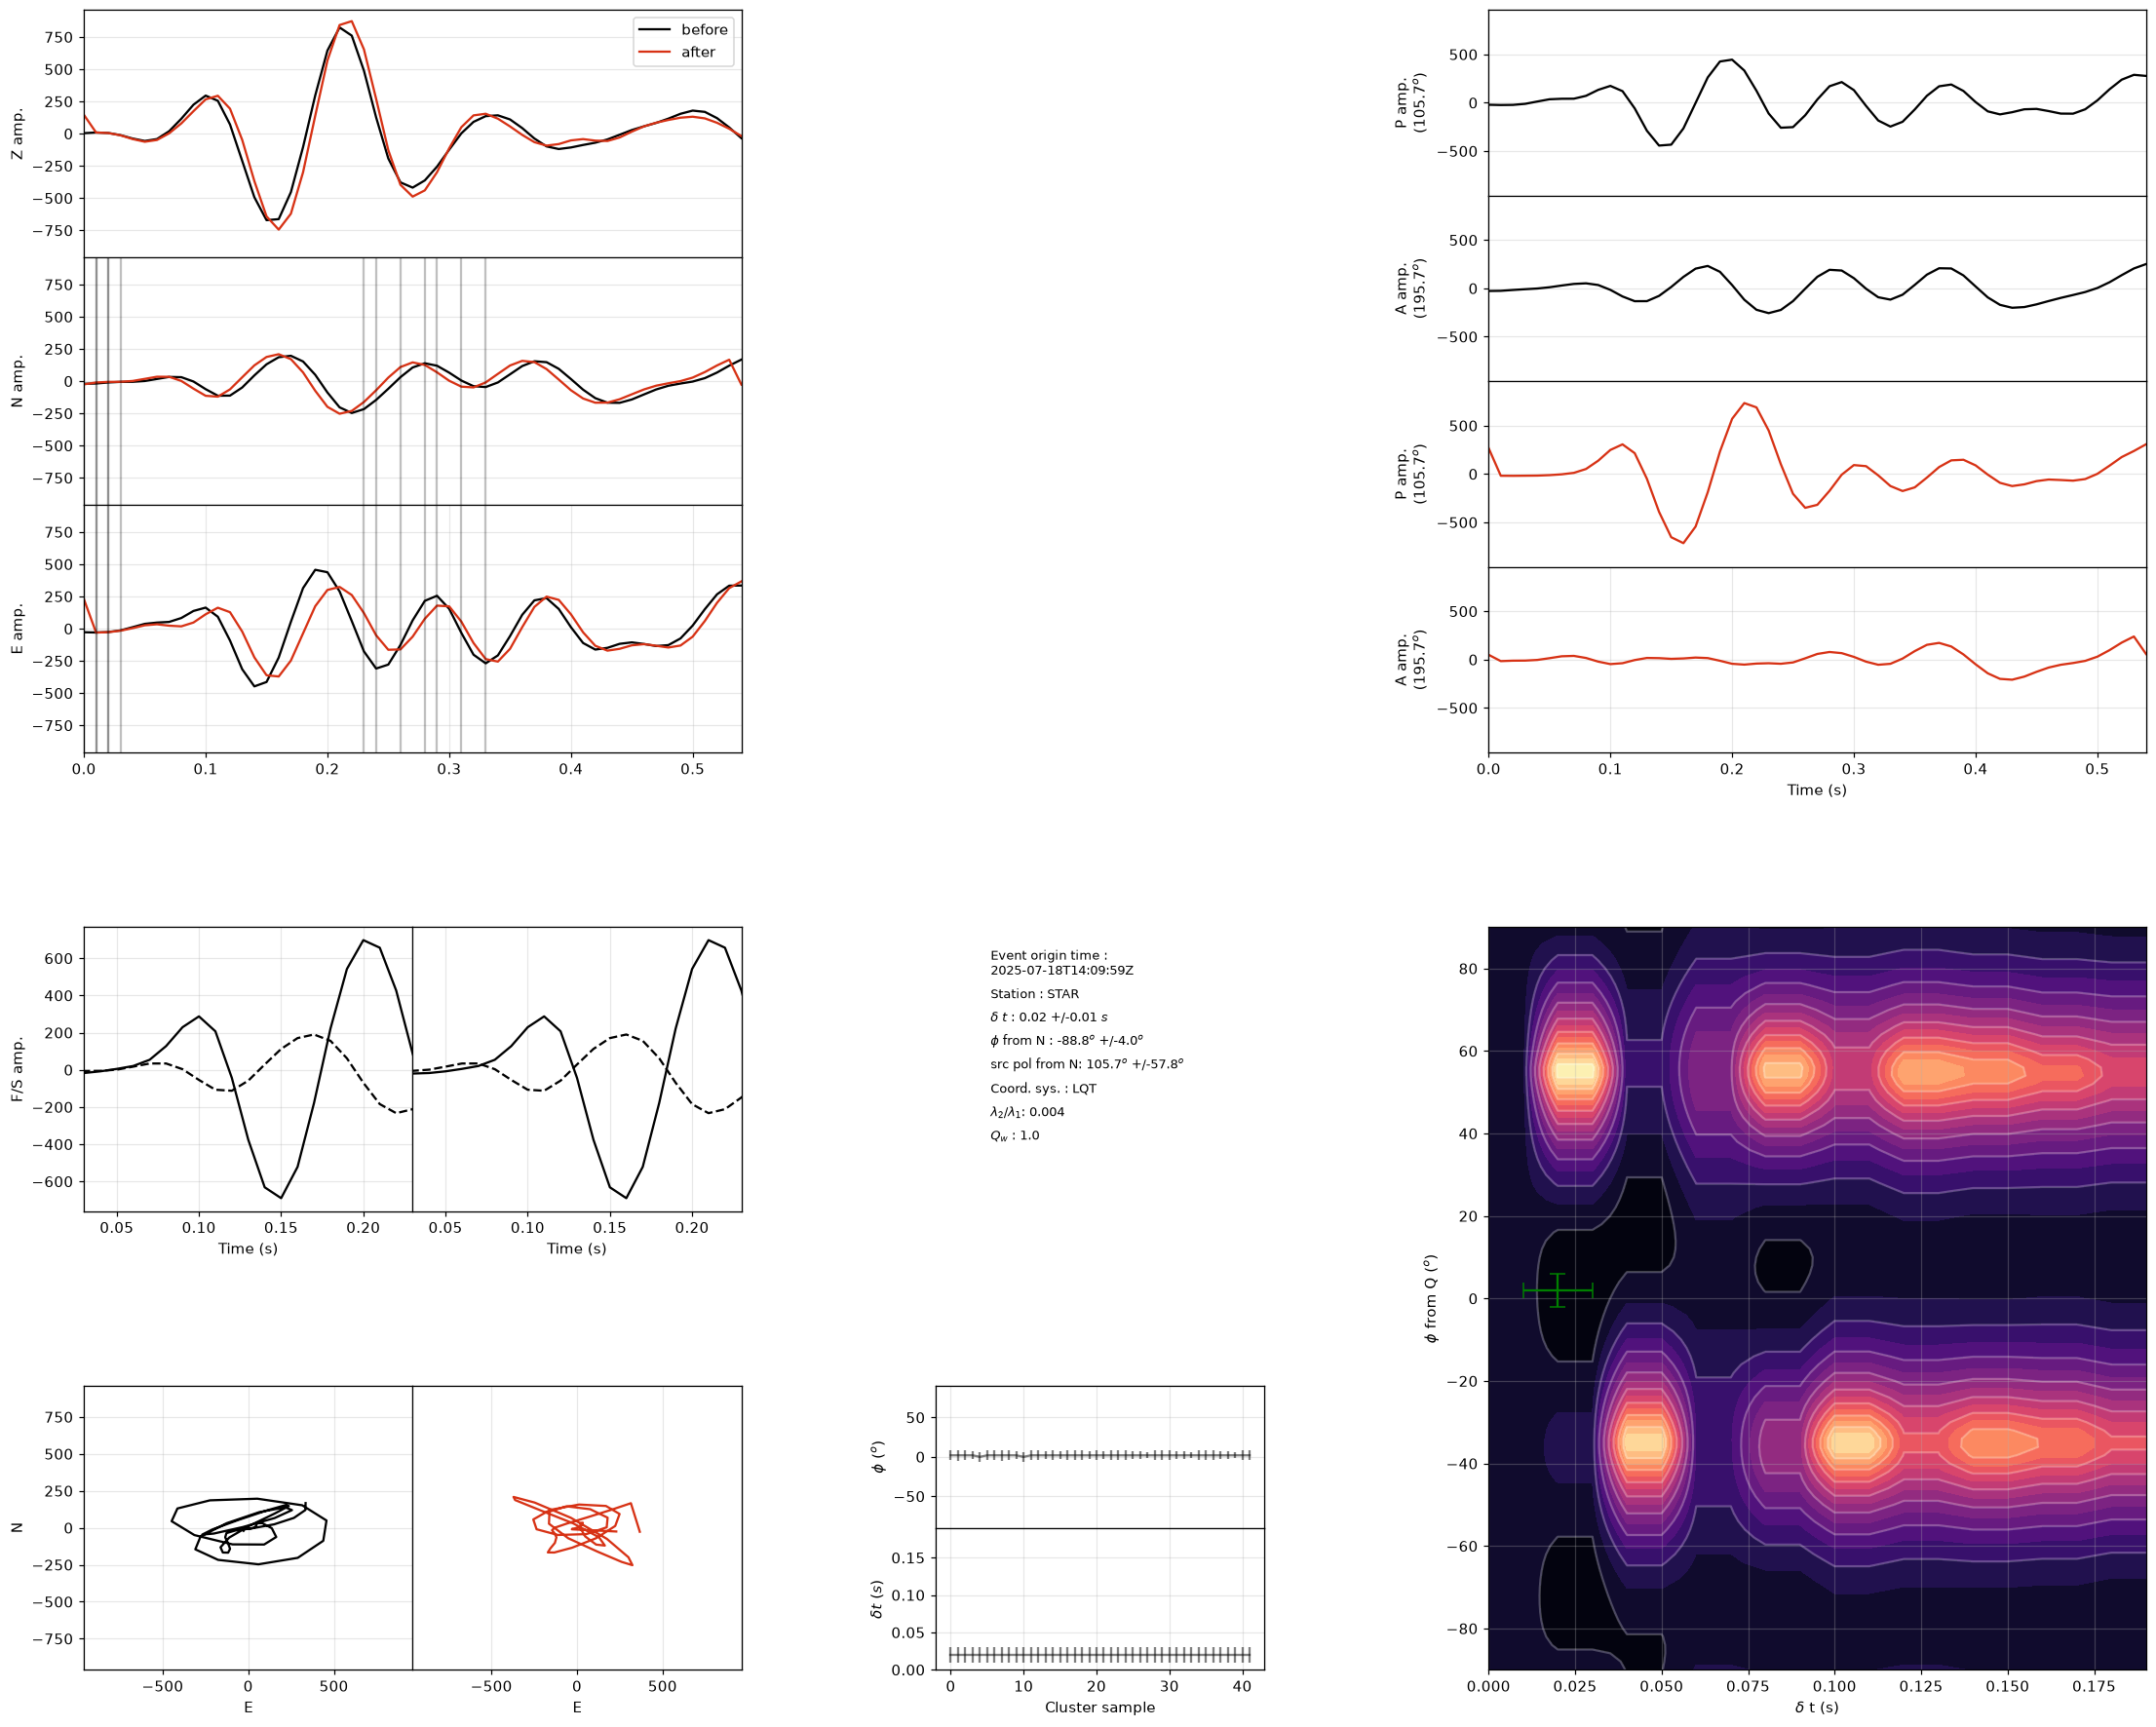

In [6]:
so = m.splitting_object
so.plot_orig(suppress_direct_plotting=False)

## 5. The same event with a different incidence angle

The incidence angle enters twice: as a gate (reject if above 45 degrees) and as the inclination of the LQT rotation that isolates the S wave. Rerun with the data-derived Jurkevics angle and with a few values in between. The measurement for this event turns out to be fairly stable; but this is one event, and the *gate* behaviour is not stable at all.

In [7]:
rows = []
for inc in [15, 25, target.incidence_angle, 35, 44, target.incidence_angle_jurkevics]:
    mm = measure.measure_event(row, ev, "STAR", lat, lon, incidence_angle=inc)
    rows.append({"incidence_used": round(inc, 1), "stage": mm.stage, "phi": mm.phi, "dt": mm.dt,
                 "phi_error": mm.phi_error, "dt_error": mm.dt_error, "Q_w": mm.quality})
pd.DataFrame(rows)

,incidence_used,stage,phi,dt,phi_error,dt_error,Q_w
0,15.0,fail_no_result,NaN,NaN,NaN,NaN,NaN
1,25.0,ok,-88.782554,0.02,5.0,0.01,0.968573
2,29.0,ok,-88.782554,0.02,4.0,0.01,1.000000
3,35.0,ok,-88.782554,0.02,5.0,0.01,1.000000
4,44.0,ok,-86.782554,0.02,4.0,0.01,1.000000
5,45.7,fail_incidence,NaN,NaN,NaN,NaN,NaN


This is the known reason PANH, OBSR, PARA, RER and COPP have (near) zero measurements in the research results: with the ray-traced angles, essentially none of their swarm events fall inside the 45-degree shear-wave window. So the question for those stations is not "is the measurement wrong" but "is the gate right, and how sensitive is everything to the velocity model behind the angle". That is a threshold question, and notebook 08 is about thresholds.

## 6. Exercises

1. Pick five more STAR events from `ref` with `stage == "ok"` and reproduce them. Keep a table of matches. Any mismatches: diagnose.
2. Pick two events with `stage == "fail_snr"` and run them with `gates=quality.PreGates(snr_min=1.0)`. Do you get a measurement? Does it pass grade 3 (`quality.grade3_mask` on a one-row DataFrame)? Would you trust it?
3. Time one measurement (`%%time`). Estimate how long all 900 STAR events take, and how long a 10-value parameter sweep over all events would take. This number decides the design of notebook 08.
4. (Stretch) In `measure_event`, the filter band is chosen before the gates are applied. Would choosing it after change anything? Why might the order matter for replicability?

Next: `07_exploring_the_results.ipynb`.